In [52]:
# Load libraries
library(tidyverse)

# Source the depth profile functions (also loads scenario_classification.R)
source("depth_profile_data.R")

# Load all profile data
profile_data <- load_profile_data()

Loaded HPLC profiles: 176 dates, depths 0-200m
Loaded cached Niskin profiles: 230 dates, depths 0-200m

=== Date Coverage Summary ===
  Total unique dates:     275
  With HPLC data:         176
  With Niskin data:       230
  With scenario class:    257
  With observed EuZ:      102


In [57]:
# Get dates with both euphotic depth observations AND chlorophyll profiles
dates_with_both <- profile_data$scenario %>%
  filter(!is.na(euphotic_depth_obs)) %>%
  filter(date %in% unique(profile_data$hplc$date)) %>%
  select(date, euphotic_depth_obs, upwelling)

cat(sprintf("Dates with both EuZ obs and HPLC profiles: %d\n", nrow(dates_with_both)))

# For each date, calculate % of chlorophyll above euphotic depth
chl_distribution <- profile_data$hplc %>%
  inner_join(dates_with_both, by = "date") %>%
  group_by(date, euphotic_depth_obs, upwelling) %>%
  summarize(
    chl_above_euz = sum(Tot_Chl_a[depth <= euphotic_depth_obs], na.rm = TRUE),
    chl_below_euz = sum(Tot_Chl_a[depth > euphotic_depth_obs], na.rm = TRUE),
    chl_total = sum(Tot_Chl_a, na.rm = TRUE),
    max_depth_sampled = max(depth),
    .groups = "drop"
  ) %>%
  mutate(
    pct_above_euz = 100 * chl_above_euz / chl_total,
    pct_below_euz = 100 * chl_below_euz / chl_total
  )

# Summary statistics
cat("\n=== Chlorophyll Distribution Relative to Euphotic Depth ===\n")
chl_distribution %>%
  summarize(
    n = n(),
    mean_pct_above = mean(pct_above_euz, na.rm = TRUE),
    sd_pct_above = sd(pct_above_euz, na.rm = TRUE),
    min_pct_above = min(pct_above_euz, na.rm = TRUE),
    max_pct_above = max(pct_above_euz, na.rm = TRUE),
    mean_euz = mean(euphotic_depth_obs, na.rm = TRUE)
  ) %>%
  print()

# Breakdown by upwelling scenario
cat("\n=== By Upwelling Scenario ===\n")
chl_distribution %>%
  group_by(upwelling) %>%
  summarize(
    n = n(),
    mean_pct_above = mean(pct_above_euz, na.rm = TRUE),
    sd_pct_above = sd(pct_above_euz, na.rm = TRUE),
    mean_euz = mean(euphotic_depth_obs, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  print()

# Show individual dates
head(chl_distribution %>% arrange(pct_above_euz), 10)

Dates with both EuZ obs and HPLC profiles: 73

=== Chlorophyll Distribution Relative to Euphotic Depth ===
# A tibble: 1 × 6
      n mean_pct_above sd_pct_above min_pct_above max_pct_above mean_euz
  <int>          <dbl>        <dbl>         <dbl>         <dbl>    <dbl>
1    73           68.4         18.3          17.5           100     45.9

=== By Upwelling Scenario ===
# A tibble: 3 × 5
  upwelling     n mean_pct_above sd_pct_above mean_euz
  <chr>     <int>          <dbl>        <dbl>    <dbl>
1 relaxed      43           67.7         18.4     51.3
2 upwelling    26           69.0         19.5     37.5
3 NA            4           72.6         10.7     43.3


date,euphotic_depth_obs,upwelling,chl_above_euz,chl_below_euz,chl_total,max_depth_sampled,pct_above_euz,pct_below_euz
<date>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1999-01-12,28.5,upwelling,2.933525,13.785256,16.718781,200,17.54628,82.45372
2006-11-02,32.6,relaxed,4.749146,15.160533,19.909679,200,23.85345,76.14655
2000-09-12,37.0,relaxed,8.748036,17.007025,25.755061,200,33.96628,66.03372
1999-09-14,50.0,relaxed,7.913127,15.029236,22.942363,200,34.49133,65.50867
2009-11-10,50.9,relaxed,8.167288,14.932085,23.099373,200,35.35718,64.64282
1999-08-11,47.8,relaxed,11.083943,17.290839,28.374781,200,39.06265,60.93735
2000-07-07,15.9,upwelling,2.017858,3.130911,5.148769,200,39.19107,60.80893
2012-03-16,12.4,upwelling,112.925456,141.996598,254.922054,200,44.29803,55.70197
1999-07-15,40.0,relaxed,13.602120,16.135161,29.737281,200,45.74097,54.25903


In [55]:
# Fit linear model: EuZ ~ Isotherm_21
proxy_model <- fit_euphotic_proxy(profile_data$scenario)

# View predictions
head(proxy_model$predictions, 30)

Fitting EuZ proxy model on 94 observations...
  Model: EuZ = 20.82 + 0.268 * Isotherm_21
  R-squared: 0.411


date,Isotherm_21,upwelling,euphotic_depth_obs,euphotic_depth_predicted,euphotic_depth_best
<date>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1995-11-08,131,relaxed,NA,55.96490,55.96490
1995-12-14,115,relaxed,NA,51.67260,51.67260
1996-01-13,103,relaxed,NA,48.45337,48.45337
1996-02-14,96,relaxed,NA,46.57549,46.57549
1996-03-13,49,upwelling,NA,33.96684,33.96684
1996-04-16,49,upwelling,NA,33.96684,33.96684
1996-05-09,32,upwelling,NA,29.40627,29.40627
1996-06-12,82,upwelling,NA,42.81972,42.81972
1996-07-10,109,relaxed,NA,50.06298,50.06298


Warning message:
“Removed 135 rows containing missing values or values outside the scale range
(`geom_point()`).”


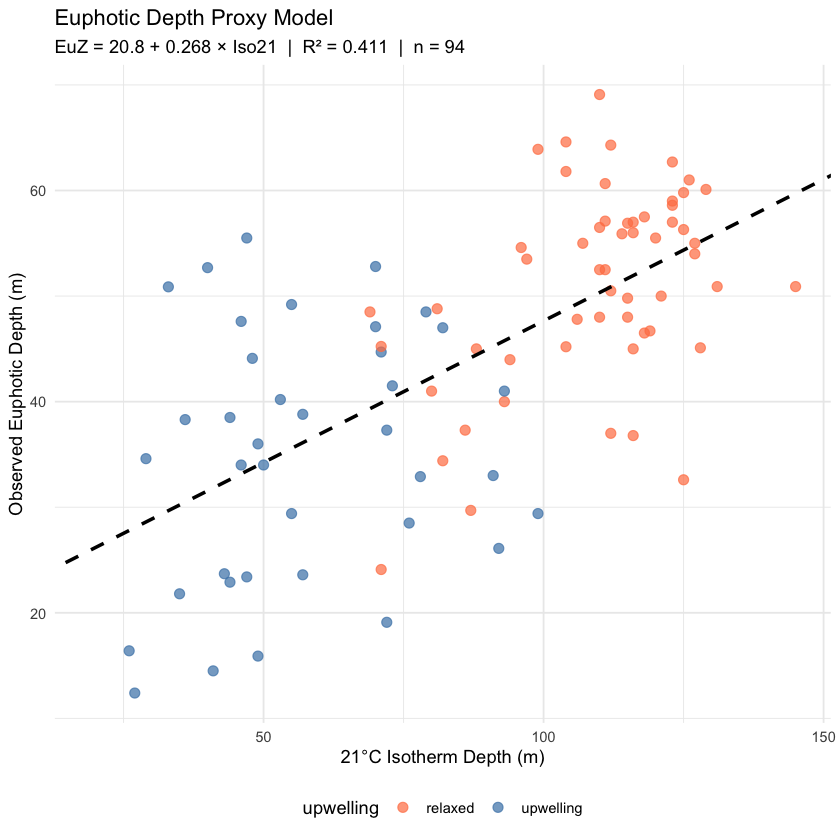

In [56]:
ggplot(proxy_model$predictions, aes(x = Isotherm_21, y = euphotic_depth_obs)) +
  geom_point(aes(color = upwelling), alpha = 0.7, size = 2.5) +
  geom_abline(intercept = proxy_model$intercept, slope = proxy_model$slope,
              linetype = "dashed", color = "black", linewidth = 1) +
  labs(
    x = "21°C Isotherm Depth (m)",
    y = "Observed Euphotic Depth (m)",
    title = "Euphotic Depth Proxy Model",
    subtitle = sprintf("EuZ = %.1f + %.3f × Iso21  |  R² = %.3f  |  n = %d",
                       proxy_model$intercept, proxy_model$slope, 
                       proxy_model$r_squared, proxy_model$n_obs)
  ) +
  scale_color_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  theme_minimal() +
  theme(legend.position = "bottom")

In [8]:
# Find dates with both HPLC and scenario data for each upwelling state
profile_dates <- profile_data$dates_summary %>%
  filter(has_hplc & has_scenario & !is.na(upwelling))

# Pick example dates (adjust as needed)
example_upwelling <- profile_dates %>% 
  filter(upwelling == "upwelling") %>%
  slice(5) %>% 
  pull(date)

example_relaxed <- profile_dates %>% 
  filter(upwelling == "relaxed") %>%
  slice(5) %>% 
  pull(date)

cat("Example upwelling date:", as.character(example_upwelling), "\n")
cat("Example relaxed date:", as.character(example_relaxed), "\n")

Example upwelling date: 1996-08-06 
Example relaxed date: 1997-09-17 


Warning message:
“Removed 225 rows containing missing values or values outside the scale range
(`geom_path()`).”
Warning message:
“Removed 225 rows containing missing values or values outside the scale range
(`geom_point()`).”


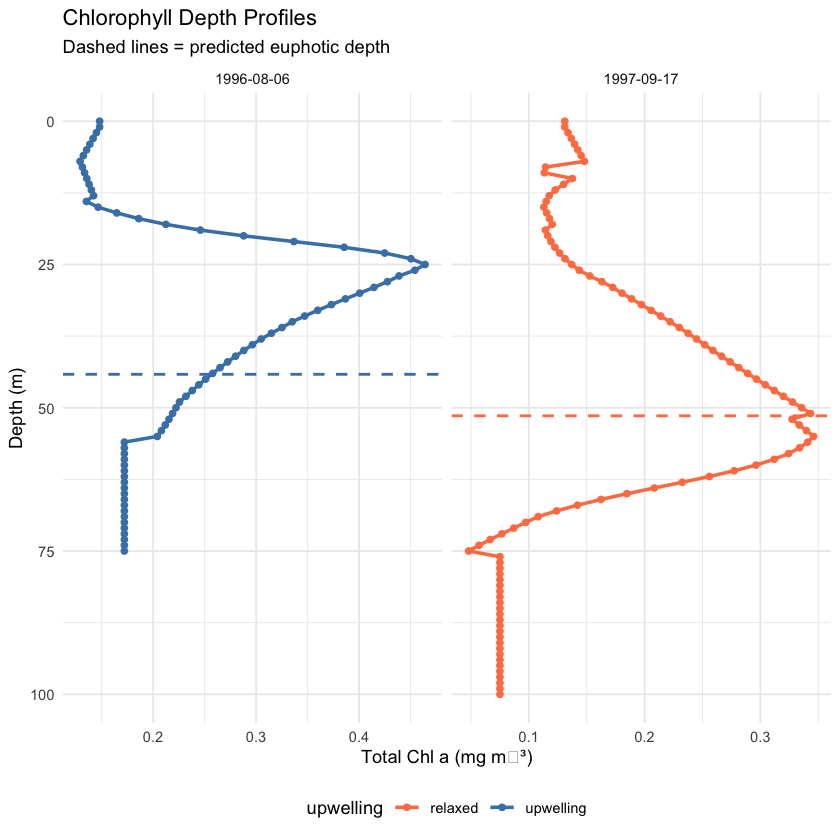

In [9]:
# Get predicted euphotic depths for these dates
example_cutoffs <- proxy_model$predictions %>%
  filter(date %in% c(example_upwelling, example_relaxed)) %>%
  select(date, upwelling, euphotic_depth_best)

# Extract profiles for example dates
example_profiles <- profile_data$hplc %>%
  filter(date %in% c(example_upwelling, example_relaxed)) %>%
  left_join(profile_data$scenario %>% select(date, upwelling), by = "date")

# Plot Tot_Chl_a profiles
ggplot(example_profiles, aes(x = Tot_Chl_a, y = depth, color = upwelling)) +
  geom_path(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_hline(data = example_cutoffs, aes(yintercept = euphotic_depth_best, color = upwelling),
             linetype = "dashed", linewidth = 0.8) +
  scale_y_reverse(limits = c(100, 0)) +
  scale_color_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  labs(
    x = "Total Chl a (mg m⁻³)",
    y = "Depth (m)",
    title = "Chlorophyll Depth Profiles",
    subtitle = "Dashed lines = predicted euphotic depth"
  ) +
  facet_wrap(~date, scales = "free_x") +
  theme_minimal() +
  theme(legend.position = "bottom")

Warning message:
“Removed 720 rows containing missing values or values outside the scale range
(`geom_path()`).”
Warning message:
“Removed 720 rows containing missing values or values outside the scale range
(`geom_point()`).”


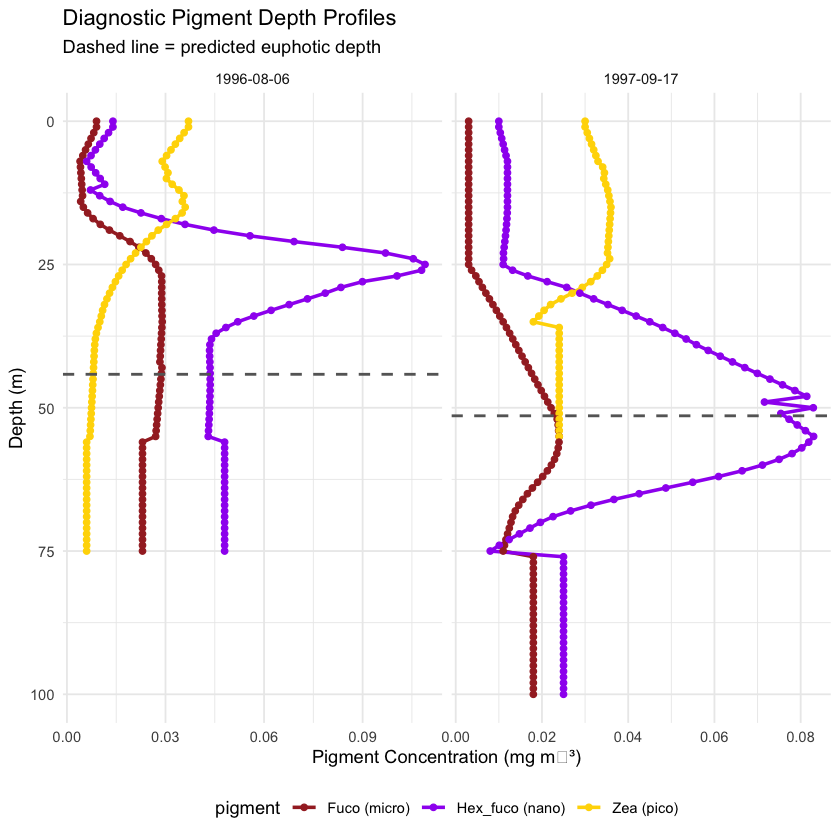

In [10]:
# Reshape for plotting multiple pigments
example_pigments_long <- example_profiles %>%
  select(date, depth, upwelling, Fuco, Zea, Hex_fuco) %>%
  pivot_longer(cols = c(Fuco, Zea, Hex_fuco), names_to = "pigment", values_to = "concentration")

ggplot(example_pigments_long, aes(x = concentration, y = depth, color = pigment)) +
  geom_path(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_hline(data = example_cutoffs, aes(yintercept = euphotic_depth_best),
             linetype = "dashed", color = "gray40", linewidth = 0.8) +
  scale_y_reverse(limits = c(100, 0)) +
  scale_color_manual(values = c("Fuco" = "brown", "Zea" = "gold", "Hex_fuco" = "purple"),
                     labels = c("Fuco (micro)", "Hex_fuco (nano)", "Zea (pico)")) +
  labs(
    x = "Pigment Concentration (mg m⁻³)",
    y = "Depth (m)",
    title = "Diagnostic Pigment Depth Profiles",
    subtitle = "Dashed line = predicted euphotic depth"
  ) +
  facet_wrap(~date, scales = "free_x") +
  theme_minimal() +
  theme(legend.position = "bottom")

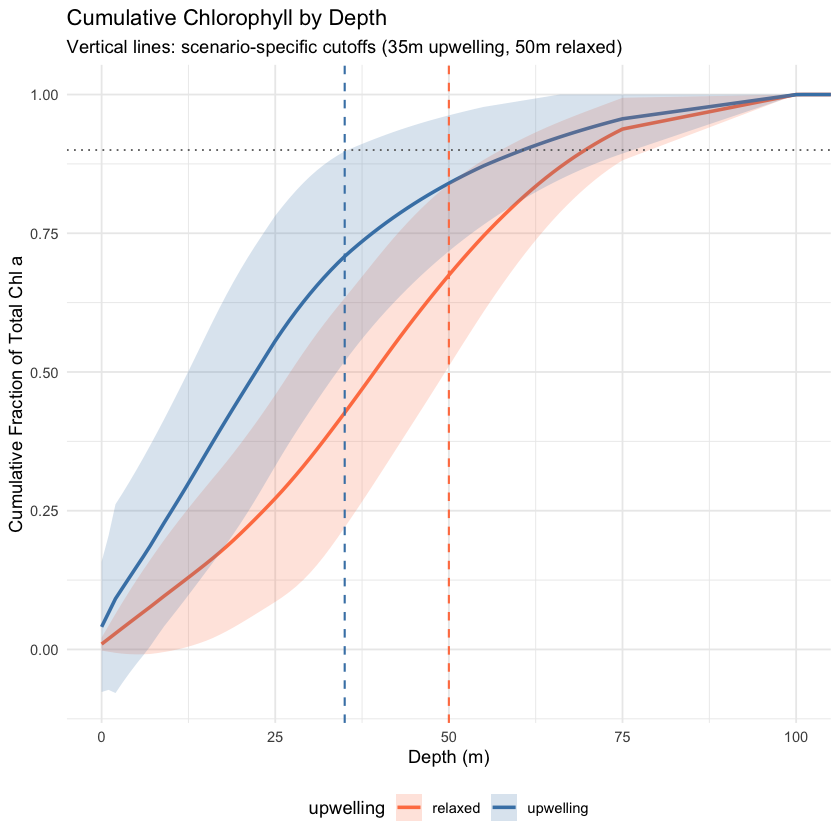

In [11]:
# Calculate cumulative integral for Tot_Chl_a
cumulative_chl <- profile_data$hplc %>%
  left_join(profile_data$scenario %>% select(date, upwelling), by = "date") %>%
  filter(!is.na(upwelling)) %>%
  group_by(date, upwelling) %>%
  arrange(depth) %>%
  mutate(
    cumsum_chl = cumsum(ifelse(is.na(Tot_Chl_a), 0, Tot_Chl_a)),
    total_chl = sum(Tot_Chl_a, na.rm = TRUE),
    frac_above = cumsum_chl / total_chl
  ) %>%
  ungroup()

# Average cumulative fraction by scenario
cumulative_summary <- cumulative_chl %>%
  group_by(upwelling, depth) %>%
  summarize(
    mean_frac = mean(frac_above, na.rm = TRUE),
    sd_frac = sd(frac_above, na.rm = TRUE),
    n = n(),
    .groups = "drop"
  )

ggplot(cumulative_summary, aes(x = depth, y = mean_frac, color = upwelling)) +
  geom_line(linewidth = 1) +
  geom_ribbon(aes(ymin = mean_frac - sd_frac, ymax = pmin(mean_frac + sd_frac, 1), 
                  fill = upwelling), alpha = 0.2, color = NA) +
  geom_hline(yintercept = 0.9, linetype = "dotted", color = "gray40") +
  geom_vline(xintercept = c(35, 50), linetype = "dashed", color = c("steelblue", "coral"), linewidth = 0.6) +
  scale_color_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  scale_fill_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  coord_cartesian(xlim = c(0, 100)) +
  labs(
    x = "Depth (m)",
    y = "Cumulative Fraction of Total Chl a",
    title = "Cumulative Chlorophyll by Depth",
    subtitle = "Vertical lines: scenario-specific cutoffs (35m upwelling, 50m relaxed)"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

In [12]:
# Compare fixed, scenario, and dynamic integration
comparison <- compare_integration_strategies(
  profile_data,
  proxy_model,
  fixed_depth = 50,
  scenario_depths = c(upwelling = 35, relaxed = 50)
)


Comparing Integration Strategies

=== Integrating profiles (mode: fixed) ===
  HPLC: 176 dates integrated
  Niskin: 230 dates integrated

=== Integrating profiles (mode: scenario) ===
  HPLC: 146 dates integrated
  Niskin: 199 dates integrated

=== Integrating profiles (mode: dynamic) ===
  HPLC: 146 dates integrated
  Niskin: 199 dates integrated


In [13]:
# Summary by strategy and upwelling state
size_fraction_summary <- comparison$hplc_comparison %>%
  filter(!is.na(micro) & !is.na(upwelling)) %>%
  group_by(strategy, upwelling) %>%
  summarize(
    n = n(),
    mean_micro = mean(micro, na.rm = TRUE),
    sd_micro = sd(micro, na.rm = TRUE),
    mean_nano = mean(nano, na.rm = TRUE),
    mean_pico = mean(pico, na.rm = TRUE),
    mean_Tot_Chl_a = mean(Tot_Chl_a_integrated, na.rm = TRUE),
    mean_depth_cutoff = mean(depth_cutoff, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(strategy = factor(strategy, levels = c("fixed", "scenario", "dynamic")))

print(size_fraction_summary)

# A tibble: 6 × 9
  strategy upwelling     n mean_micro sd_micro mean_nano mean_pico
  <fct>    <chr>     <int>      <dbl>    <dbl>     <dbl>     <dbl>
1 dynamic  relaxed      63      0.314    0.229     0.274     0.412
2 dynamic  upwelling    32      0.519    0.256     0.229     0.253
3 fixed    relaxed      63      0.313    0.227     0.273     0.414
4 fixed    upwelling    31      0.496    0.238     0.233     0.271
5 scenario relaxed      63      0.313    0.227     0.273     0.414
6 scenario upwelling    32      0.518    0.256     0.228     0.254
# ℹ 2 more variables: mean_Tot_Chl_a <dbl>, mean_depth_cutoff <dbl>


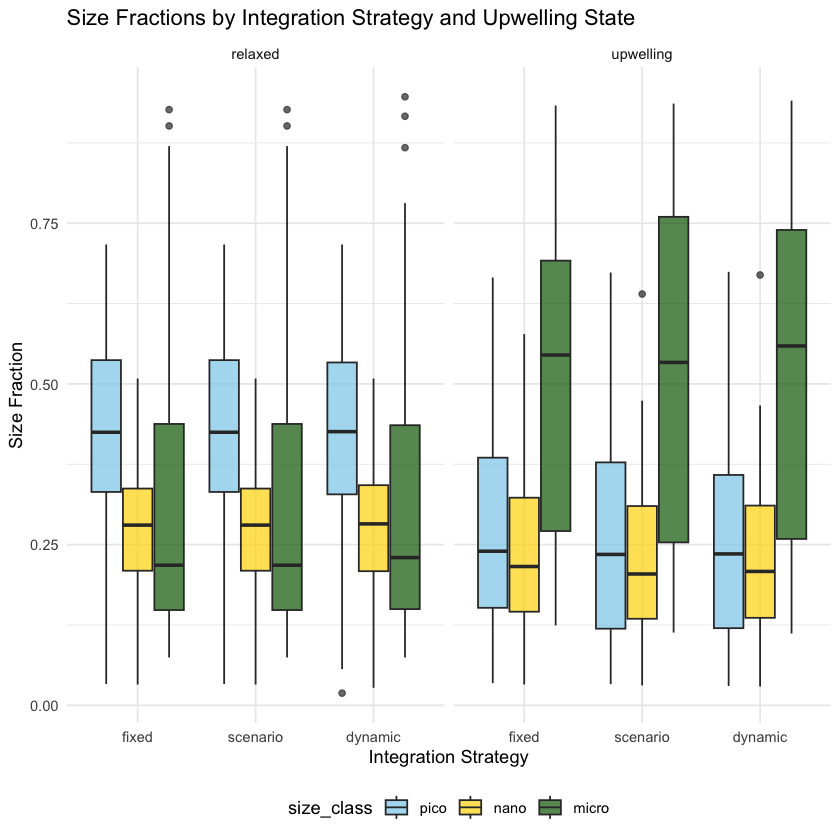

In [14]:
# Reshape for plotting
size_long <- comparison$hplc_comparison %>%
  filter(!is.na(micro) & !is.na(upwelling)) %>%
  select(date, strategy, upwelling, micro, nano, pico) %>%
  pivot_longer(cols = c(micro, nano, pico), names_to = "size_class", values_to = "fraction") %>%
  mutate(
    strategy = factor(strategy, levels = c("fixed", "scenario", "dynamic")),
    size_class = factor(size_class, levels = c("pico", "nano", "micro"))
  )

ggplot(size_long, aes(x = strategy, y = fraction, fill = size_class)) +
  geom_boxplot(position = position_dodge(0.8), alpha = 0.7) +
  facet_wrap(~upwelling) +
  scale_fill_manual(values = c("micro" = "darkgreen", "nano" = "gold", "pico" = "skyblue")) +
  labs(
    x = "Integration Strategy",
    y = "Size Fraction",
    title = "Size Fractions by Integration Strategy and Upwelling State"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

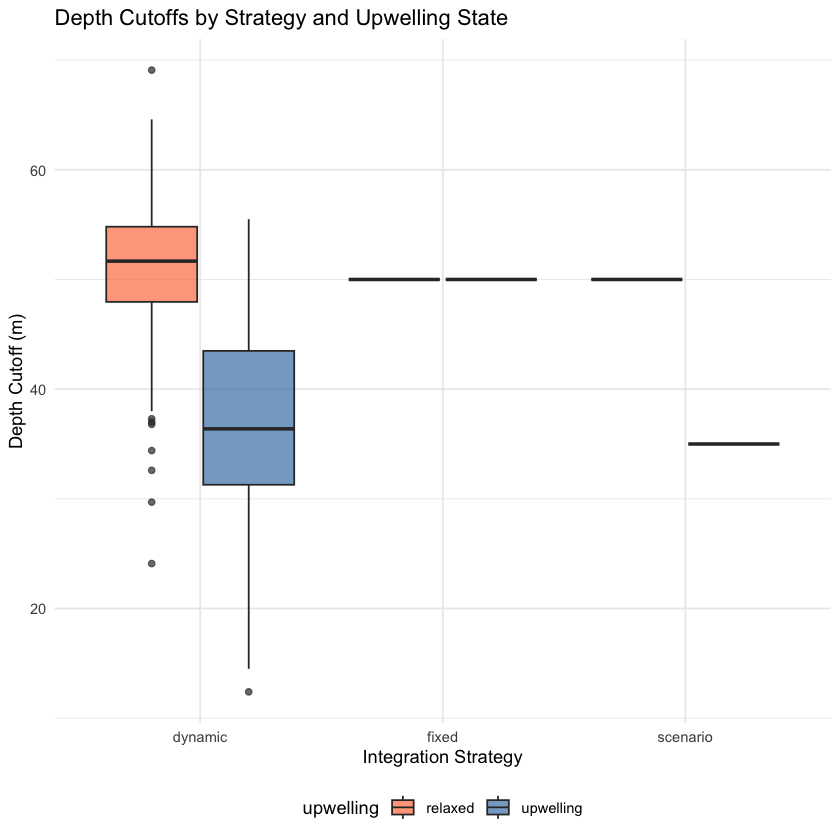

In [18]:
# How different are the depth cutoffs across strategies?
cutoff_comparison <- bind_rows(
  comparison$fixed$cutoffs %>% select(date, depth_cutoff) %>% mutate(strategy = "fixed"),
  comparison$scenario$cutoffs %>% select(date, depth_cutoff) %>% mutate(strategy = "scenario"),
  comparison$dynamic$cutoffs %>% select(date, depth_cutoff) %>% mutate(strategy = "dynamic")
) %>%
  left_join(profile_data$scenario %>% select(date, upwelling), by = "date") %>%
  filter(!is.na(upwelling) & !is.na(depth_cutoff))

ggplot(cutoff_comparison, aes(x = strategy, y = depth_cutoff, fill = upwelling)) +
  geom_boxplot(alpha = 0.7, position = position_dodge(0.8)) +
  scale_fill_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  labs(
    x = "Integration Strategy",
    y = "Depth Cutoff (m)",
    title = "Depth Cutoffs by Strategy and Upwelling State"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

In [16]:
# Compare NO3 across strategies
nutrient_summary <- comparison$niskin_comparison %>%
  filter(!is.na(NO3_merged_mean) & !is.na(upwelling)) %>%
  group_by(strategy, upwelling) %>%
  summarize(
    n = n(),
    mean_NO3 = mean(NO3_merged_mean, na.rm = TRUE),
    sd_NO3 = sd(NO3_merged_mean, na.rm = TRUE),
    mean_PP = mean(PrimaryProductivity_integrated, na.rm = TRUE),
    mean_PON = mean(PON_mmol, na.rm = TRUE),
    mean_depth_cutoff = mean(depth_cutoff, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(strategy = factor(strategy, levels = c("fixed", "scenario", "dynamic")))

print(nutrient_summary)

# A tibble: 6 × 8
  strategy upwelling     n mean_NO3 sd_NO3 mean_PP mean_PON mean_depth_cutoff
  <fct>    <chr>     <int>    <dbl>  <dbl>   <dbl>    <dbl>             <dbl>
1 dynamic  relaxed     106    0.993  0.925    77.5     8.23              50.5
2 dynamic  upwelling    76    2.05   1.45    130.     14.6               36.3
3 fixed    relaxed     106    1.04   1.00     76.8     7.97              50  
4 fixed    upwelling    76    3.42   1.62    136.     11.5               50  
5 scenario relaxed     106    1.04   1.00     76.8     7.97              50  
6 scenario upwelling    76    2.13   1.50    130.     13.8               35  


In [17]:
# Calculate grand means by strategy — for model validation
cat("\n=== Grand Means for Model Validation ===\n\n")

for (strat in c("fixed", "scenario", "dynamic")) {
  
  cat(sprintf("--- Strategy: %s ---\n", toupper(strat)))
  
  hplc_sub <- comparison$hplc_comparison %>% filter(strategy == strat)
  niskin_sub <- comparison$niskin_comparison %>% filter(strategy == strat)
  
  cat(sprintf("  Mean depth cutoff:      %.1f m\n", mean(hplc_sub$depth_cutoff, na.rm = TRUE)))
  cat(sprintf("  Tot Chl a (integrated): %.2f mg m⁻²\n", mean(hplc_sub$Tot_Chl_a_integrated, na.rm = TRUE)))
  cat(sprintf("  Micro fraction:         %.3f\n", mean(hplc_sub$micro, na.rm = TRUE)))
  cat(sprintf("  Nano fraction:          %.3f\n", mean(hplc_sub$nano, na.rm = TRUE)))
  cat(sprintf("  Pico fraction:          %.3f\n", mean(hplc_sub$pico, na.rm = TRUE)))
  cat(sprintf("  Size centroid:          %.3f\n", mean(hplc_sub$size_centroid, na.rm = TRUE)))
  cat(sprintf("  NO3 (mean):             %.3f mmol m⁻³\n", mean(niskin_sub$NO3_merged_mean, na.rm = TRUE)))
  cat(sprintf("  PON (mean):             %.3f mmol m⁻³\n", mean(niskin_sub$PON_mmol, na.rm = TRUE)))
  cat(sprintf("  PP (integrated):        %.1f mg C m⁻² d⁻¹\n", mean(niskin_sub$PrimaryProductivity_integrated, na.rm = TRUE) * 12))
  cat("\n")
}


=== Grand Means for Model Validation ===

--- Strategy: FIXED ---
  Mean depth cutoff:      50.0 m
  Tot Chl a (integrated): 30.37 mg m⁻²
  Micro fraction:         0.388
  Nano fraction:          0.253
  Pico fraction:          0.359
  Size centroid:          0.829
  NO3 (mean):             2.016 mmol m⁻³
  PON (mean):             9.409 mmol m⁻³
  PP (integrated):        1197.9 mg C m⁻² d⁻¹

--- Strategy: SCENARIO ---
  Mean depth cutoff:      44.0 m
  Tot Chl a (integrated): 28.26 mg m⁻²
  Micro fraction:         0.382
  Nano fraction:          0.258
  Pico fraction:          0.360
  Size centroid:          0.822
  NO3 (mean):             1.493 mmol m⁻³
  PON (mean):             10.231 mmol m⁻³
  PP (integrated):        1161.7 mg C m⁻² d⁻¹

--- Strategy: DYNAMIC ---
  Mean depth cutoff:      45.3 m
  Tot Chl a (integrated): 27.88 mg m⁻²
  Micro fraction:         0.383
  Nano fraction:          0.259
  Pico fraction:          0.358
  Size centroid:          0.824
  NO3 (mean):        

In [22]:
# Calculate DCM depth and compare to euphotic depth cutoff
dcm_analysis <- profile_data$hplc %>%
  left_join(profile_data$scenario %>% select(date, upwelling, Isotherm_21), by = "date") %>%
  left_join(proxy_model$predictions %>% select(date, euphotic_depth_best), by = "date") %>%
  filter(!is.na(upwelling) & !is.na(Tot_Chl_a)) %>%
  group_by(date, upwelling, euphotic_depth_best) %>%
  summarize(
    dcm_depth = depth[which.max(Tot_Chl_a)],
    dcm_value = max(Tot_Chl_a, na.rm = TRUE),
    surface_chl = first(Tot_Chl_a[depth <= 5]),  # Use shallowest available instead of exact 0
    .groups = "drop"
  ) %>%
  filter(!is.na(dcm_depth)) %>%
  mutate(
    dcm_below_euz = dcm_depth > euphotic_depth_best,
    dcm_euz_diff = dcm_depth - euphotic_depth_best
  )

# Summary statistics
dcm_summary <- dcm_analysis %>%
  group_by(upwelling) %>%
  summarize(
    n = n(),
    mean_dcm_depth = mean(dcm_depth, na.rm = TRUE),
    sd_dcm_depth = sd(dcm_depth, na.rm = TRUE),
    mean_euz_depth = mean(euphotic_depth_best, na.rm = TRUE),
    pct_dcm_below_euz = 100 * mean(dcm_below_euz, na.rm = TRUE),
    mean_dcm_euz_diff = mean(dcm_euz_diff, na.rm = TRUE),
    .groups = "drop"
  )

print(dcm_summary)

# A tibble: 2 × 7
  upwelling     n mean_dcm_depth sd_dcm_depth mean_euz_depth pct_dcm_below_euz
  <chr>     <int>          <dbl>        <dbl>          <dbl>             <dbl>
1 relaxed      85           37.5         15.3           51.0             21.2 
2 upwelling    53           18.3         11.7           37.3              9.43
# ℹ 1 more variable: mean_dcm_euz_diff <dbl>


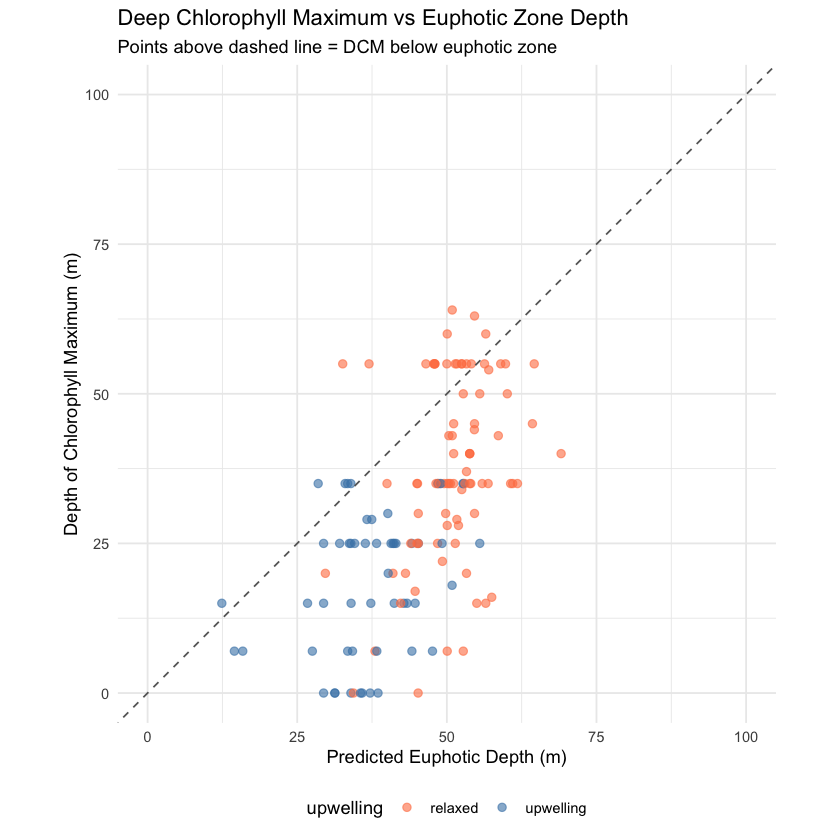

In [24]:
ggplot(dcm_analysis, aes(x = euphotic_depth_best, y = dcm_depth, color = upwelling)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray40") +
  scale_color_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  labs(
    x = "Predicted Euphotic Depth (m)",
    y = "Depth of Chlorophyll Maximum (m)",
    title = "Deep Chlorophyll Maximum vs Euphotic Zone Depth",
    subtitle = "Points above dashed line = DCM below euphotic zone"
  ) +
  coord_fixed(xlim = c(0, 100), ylim = c(0, 100)) +
  theme_minimal() +
  theme(legend.position = "bottom")

In [21]:
# Calculate cumulative fraction at specific depth thresholds
depth_thresholds <- c(30, 35, 40, 50, 60, 75, 100)

biomass_capture <- profile_data$hplc %>%
  left_join(profile_data$scenario %>% select(date, upwelling), by = "date") %>%
  filter(!is.na(upwelling) & !is.na(Tot_Chl_a)) %>%
  group_by(date, upwelling) %>%
  mutate(total_biomass = sum(Tot_Chl_a, na.rm = TRUE)) %>%
  ungroup()

# Calculate fraction captured at each threshold
capture_by_threshold <- map_dfr(depth_thresholds, function(d) {
  biomass_capture %>%
    filter(depth <= d) %>%
    group_by(date, upwelling, total_biomass) %>%
    summarize(biomass_above = sum(Tot_Chl_a, na.rm = TRUE), .groups = "drop") %>%
    mutate(
      fraction_captured = biomass_above / total_biomass,
      depth_threshold = d
    )
})

# Summary by scenario and threshold
capture_summary <- capture_by_threshold %>%
  group_by(upwelling, depth_threshold) %>%
  summarize(
    mean_fraction = mean(fraction_captured, na.rm = TRUE),
    sd_fraction = sd(fraction_captured, na.rm = TRUE),
    median_fraction = median(fraction_captured, na.rm = TRUE),
    n = n(),
    .groups = "drop"
  )

print(capture_summary %>% pivot_wider(names_from = upwelling, values_from = c(mean_fraction, median_fraction)))

# A tibble: 14 × 7
   depth_threshold sd_fraction     n mean_fraction_relaxed
             <dbl>       <dbl> <int>                 <dbl>
 1              30    0.207       85                 0.345
 2              35    0.207       85                 0.427
 3              40    0.198       85                 0.513
 4              50    0.164       85                 0.675
 5              60    0.109       85                 0.807
 6              75    0.0564      85                 0.938
 7             100    0.000116    85                 1.000
 8              30    0.211       53                NA    
 9              35    0.189       53                NA    
10              40    0.163       53                NA    
11              50    0.122       53                NA    
12              60    0.0909      53                NA    
13              75    0.0626      53                NA    
14             100    0.00125     53                NA    
# ℹ 3 more variables: mean_fraction_u

In [23]:
# Cleaner summary table
capture_clean <- capture_summary %>%
  select(upwelling, depth_threshold, mean_fraction) %>%
  pivot_wider(names_from = upwelling, values_from = mean_fraction, names_prefix = "frac_") %>%
  mutate(
    pct_relaxed = round(100 * frac_relaxed, 1),
    pct_upwelling = round(100 * frac_upwelling, 1)
  ) %>%
  select(depth_threshold, pct_upwelling, pct_relaxed)

cat("=== % of Total Chl a Captured at Each Depth ===\n\n")
print(capture_clean)

=== % of Total Chl a Captured at Each Depth ===

# A tibble: 7 × 3
  depth_threshold pct_upwelling pct_relaxed
            <dbl>         <dbl>       <dbl>
1              30          64.1        34.5
2              35          70.8        42.7
3              40          76          51.3
4              50          84          67.5
5              60          89.7        80.7
6              75          95.6        93.8
7             100         100         100  


In [27]:
# For each date, check if DCM is captured under each strategy
dcm_capture_comparison <- dcm_analysis %>%
  mutate(
    scenario_cutoff = ifelse(upwelling == "upwelling", 35, 50),
    dynamic_cutoff = euphotic_depth_best,
    
    # Is DCM captured?
    dcm_captured_scenario = dcm_depth <= scenario_cutoff,
    dcm_captured_dynamic = dcm_depth <= dynamic_cutoff,
    
    # Difference in cutoffs
    cutoff_diff = dynamic_cutoff - scenario_cutoff
  )

# Summary: what % of DCMs are captured by each strategy?
dcm_capture_summary <- dcm_capture_comparison %>%
  group_by(upwelling) %>%
  summarize(
    n = n(),
    mean_scenario_cutoff = mean(scenario_cutoff),
    mean_dynamic_cutoff = mean(dynamic_cutoff, na.rm = TRUE),
    pct_dcm_captured_scenario = 100 * mean(dcm_captured_scenario, na.rm = TRUE),
    pct_dcm_captured_dynamic = 100 * mean(dcm_captured_dynamic, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    dcm_capture_diff = pct_dcm_captured_dynamic - pct_dcm_captured_scenario
  )

dcm_capture_summary

upwelling,n,mean_scenario_cutoff,mean_dynamic_cutoff,pct_dcm_captured_scenario,pct_dcm_captured_dynamic,dcm_capture_diff
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
relaxed,85,50,51.0205,72.94118,78.82353,5.882353
upwelling,53,35,37.2584,100.00000,90.56604,-9.433962


In [29]:
# Calculate biomass captured under each strategy for each date
biomass_comparison <- profile_data$hplc %>%
  left_join(profile_data$scenario %>% select(date, upwelling), by = "date") %>%
  left_join(proxy_model$predictions %>% select(date, euphotic_depth_best), by = "date") %>%
  filter(!is.na(upwelling) & !is.na(euphotic_depth_best) & !is.na(Tot_Chl_a)) %>%
  mutate(
    scenario_cutoff = ifelse(upwelling == "upwelling", 35, 50)
  ) %>%
  group_by(date, upwelling, scenario_cutoff, euphotic_depth_best) %>%
  summarize(
    total_biomass = sum(Tot_Chl_a, na.rm = TRUE),
    biomass_scenario = sum(Tot_Chl_a[depth <= scenario_cutoff], na.rm = TRUE),
    biomass_dynamic = sum(Tot_Chl_a[depth <= euphotic_depth_best], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    frac_scenario = biomass_scenario / total_biomass,
    frac_dynamic = biomass_dynamic / total_biomass,
    frac_diff = frac_dynamic - frac_scenario,
    cutoff_diff = euphotic_depth_best - scenario_cutoff
  )

# Summary by scenario
biomass_capture_summary <- biomass_comparison %>%
  group_by(upwelling) %>%
  summarize(
    n = n(),
    mean_cutoff_scenario = mean(scenario_cutoff),
    mean_cutoff_dynamic = mean(euphotic_depth_best, na.rm = TRUE),
    mean_frac_scenario = mean(frac_scenario, na.rm = TRUE),
    mean_frac_dynamic = mean(frac_dynamic, na.rm = TRUE),
    mean_frac_diff = mean(frac_diff, na.rm = TRUE),
    .groups = "drop"
  )

cat("=== Biomass Capture: Scenario vs Dynamic ===\n\n")
biomass_capture_summary

=== Biomass Capture: Scenario vs Dynamic ===



upwelling,n,mean_cutoff_scenario,mean_cutoff_dynamic,mean_frac_scenario,mean_frac_dynamic,mean_frac_diff
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
relaxed,85,50,51.0205,0.6745183,0.6934608,0.01894258
upwelling,53,35,37.2584,0.7083728,0.7205478,0.01217509


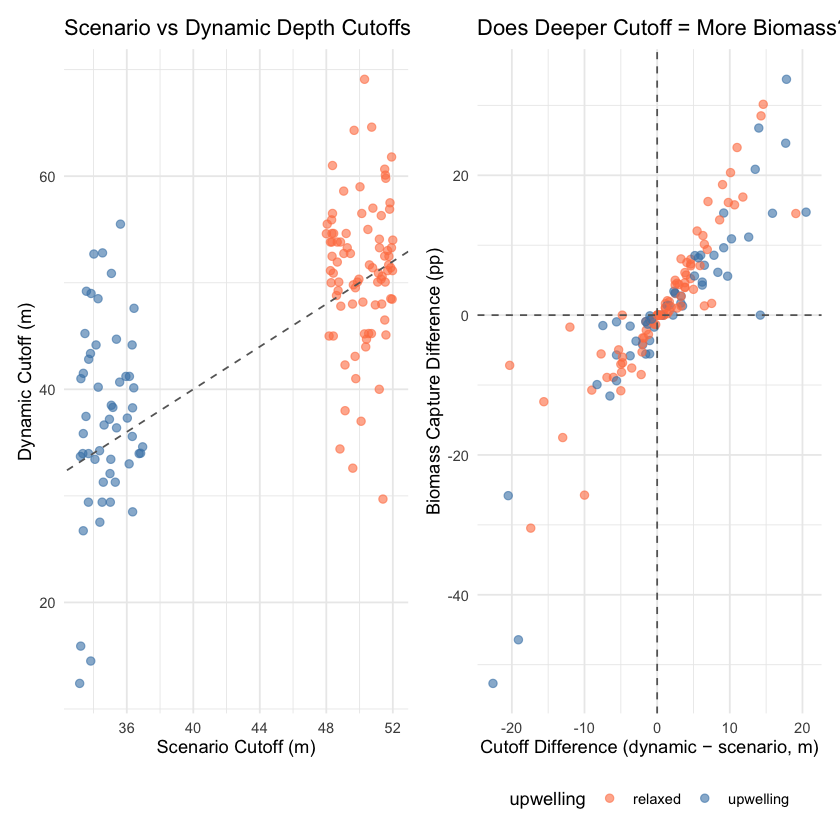

In [30]:
# Scatter: scenario cutoff vs dynamic cutoff
p1 <- ggplot(biomass_comparison, aes(x = scenario_cutoff, y = euphotic_depth_best, color = upwelling)) +
  geom_jitter(width = 2, alpha = 0.6, size = 2) +
  geom_abline(intercept = 0, slope = 1, linetype = "dashed", color = "gray40") +
  scale_color_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  labs(
    x = "Scenario Cutoff (m)",
    y = "Dynamic Cutoff (m)",
    title = "Scenario vs Dynamic Depth Cutoffs"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

# Scatter: cutoff difference vs biomass capture difference
p2 <- ggplot(biomass_comparison, aes(x = cutoff_diff, y = frac_diff * 100, color = upwelling)) +
  geom_point(alpha = 0.6, size = 2) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray40") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray40") +
  scale_color_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  labs(
    x = "Cutoff Difference (dynamic − scenario, m)",
    y = "Biomass Capture Difference (pp)",
    title = "Does Deeper Cutoff = More Biomass?"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

library(patchwork)
p1 + p2

In [31]:
# Paired comparison: does dynamic capture significantly more biomass?
cat("=== Paired t-test: Dynamic vs Scenario Biomass Capture ===\n\n")

# Overall
t_overall <- t.test(biomass_comparison$frac_dynamic, 
                    biomass_comparison$frac_scenario, 
                    paired = TRUE)
cat("Overall:\n")
cat(sprintf("  Mean scenario: %.1f%%\n", 100 * mean(biomass_comparison$frac_scenario)))
cat(sprintf("  Mean dynamic:  %.1f%%\n", 100 * mean(biomass_comparison$frac_dynamic)))
cat(sprintf("  Difference:    %.2f pp\n", 100 * mean(biomass_comparison$frac_diff)))
cat(sprintf("  p-value:       %.4f\n\n", t_overall$p.value))

# By scenario
for (scen in c("upwelling", "relaxed")) {
  sub <- biomass_comparison %>% filter(upwelling == scen)
  t_sub <- t.test(sub$frac_dynamic, sub$frac_scenario, paired = TRUE)
  cat(sprintf("%s:\n", toupper(scen)))
  cat(sprintf("  Mean scenario: %.1f%%\n", 100 * mean(sub$frac_scenario)))
  cat(sprintf("  Mean dynamic:  %.1f%%\n", 100 * mean(sub$frac_dynamic)))
  cat(sprintf("  Difference:    %.2f pp\n", 100 * mean(sub$frac_diff)))
  cat(sprintf("  p-value:       %.4f\n\n", t_sub$p.value))
}

=== Paired t-test: Dynamic vs Scenario Biomass Capture ===

Overall:
  Mean scenario: 68.8%
  Mean dynamic:  70.4%
  Difference:    1.63 pp
  p-value:       0.1025

UPWELLING:
  Mean scenario: 70.8%
  Mean dynamic:  72.1%
  Difference:    1.22 pp
  p-value:       0.5338

RELAXED:
  Mean scenario: 67.5%
  Mean dynamic:  69.3%
  Difference:    1.89 pp
  p-value:       0.0819



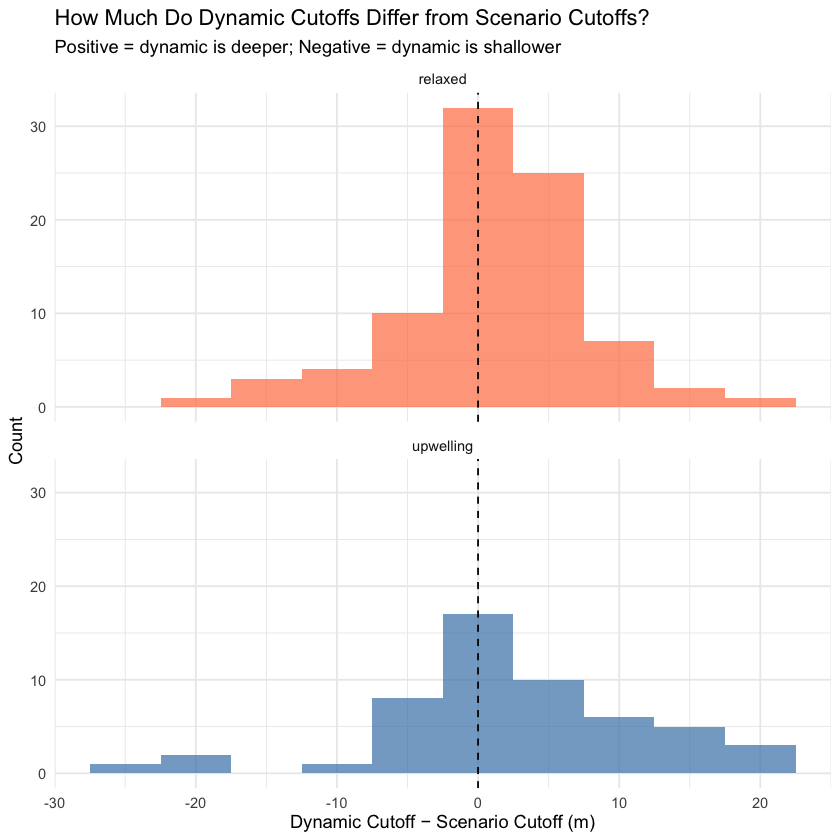

In [32]:
# Histogram of cutoff differences by scenario
ggplot(biomass_comparison, aes(x = cutoff_diff, fill = upwelling)) +
  geom_histogram(binwidth = 5, alpha = 0.7, position = "identity") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "black") +
  scale_fill_manual(values = c("upwelling" = "steelblue", "relaxed" = "coral")) +
  facet_wrap(~upwelling, ncol = 1) +
  labs(
    x = "Dynamic Cutoff − Scenario Cutoff (m)",
    y = "Count",
    title = "How Much Do Dynamic Cutoffs Differ from Scenario Cutoffs?",
    subtitle = "Positive = dynamic is deeper; Negative = dynamic is shallower"
  ) +
  theme_minimal() +
  theme(legend.position = "none")

In [39]:
# Recalculate with explicit NA handling for sd
scenario_means_hplc <- comparison$scenario$hplc %>%
  filter(!is.na(upwelling) & !is.na(micro)) %>%
  group_by(upwelling) %>%
  summarize(
    n = n(),
    depth_cutoff = mean(depth_cutoff, na.rm = TRUE),
    Tot_Chl_a = mean(Tot_Chl_a_integrated, na.rm = TRUE),
    sd_Tot_Chl_a = sd(Tot_Chl_a_integrated, na.rm = TRUE),
    micro = mean(micro, na.rm = TRUE),
    sd_micro = sd(micro, na.rm = TRUE),
    nano = mean(nano, na.rm = TRUE),
    sd_nano = sd(nano, na.rm = TRUE),
    pico = mean(pico, na.rm = TRUE),
    sd_pico = sd(pico, na.rm = TRUE),
    size_centroid = mean(size_centroid, na.rm = TRUE),
    sd_size_centroid = sd(size_centroid, na.rm = TRUE),
    nbss_slope = mean(nbss_slope, na.rm = TRUE),
    sd_nbss_slope = sd(nbss_slope, na.rm = TRUE),
    .groups = "drop"
  )

scenario_means_niskin <- comparison$scenario$niskin %>%
  filter(!is.na(upwelling)) %>%
  group_by(upwelling) %>%
  summarize(
    n_niskin = n(),
    NO3 = mean(NO3_merged_mean, na.rm = TRUE),
    sd_NO3 = sd(NO3_merged_mean, na.rm = TRUE),
    PON = mean(PON_mmol, na.rm = TRUE),
    sd_PON = sd(PON_mmol, na.rm = TRUE),
    PP = mean(PrimaryProductivity_integrated, na.rm = TRUE) * 12,
    sd_PP = sd(PrimaryProductivity_integrated, na.rm = TRUE) * 12,
    Temp = mean(Temperature_mean, na.rm = TRUE),
    sd_Temp = sd(Temperature_mean, na.rm = TRUE),
    .groups = "drop"
  )

scenario_validation <- left_join(scenario_means_hplc, scenario_means_niskin, by = "upwelling")

print(scenario_validation)

# A tibble: 2 × 24
  upwelling     n depth_cutoff Tot_Chl_a sd_Tot_Chl_a micro sd_micro  nano
  <chr>     <int>        <dbl>     <dbl>        <dbl> <dbl>    <dbl> <dbl>
1 relaxed      63           50      24.1         19.5 0.313       NA 0.273
2 upwelling    32           35      29.2         26.3 0.518       NA 0.228
# ℹ 16 more variables: sd_nano <dbl>, pico <dbl>, sd_pico <dbl>,
#   size_centroid <dbl>, sd_size_centroid <dbl>, nbss_slope <dbl>,
#   sd_nbss_slope <dbl>, n_niskin <int>, NO3 <dbl>, sd_NO3 <dbl>, PON <dbl>,
#   sd_PON <dbl>, PP <dbl>, sd_PP <dbl>, Temp <dbl>, sd_Temp <dbl>


In [37]:
# Check the structure of the integrated data
comparison$scenario$hplc %>%
  filter(!is.na(upwelling)) %>%
  group_by(upwelling) %>%
  summarize(
    n_total = n(),
    n_micro_valid = sum(!is.na(micro)),
    n_nano_valid = sum(!is.na(nano)),
    n_pico_valid = sum(!is.na(pico)),
    .groups = "drop"
  )

upwelling,n_total,n_micro_valid,n_nano_valid,n_pico_valid
<chr>,<int>,<int>,<int>,<int>
relaxed,88,63,63,63
upwelling,58,32,32,32


In [40]:
# Look at the actual data
comparison$scenario$hplc %>%
  filter(!is.na(upwelling)) %>%
  select(date, upwelling, micro, nano, pico) %>%
  head(20)

date,upwelling,micro,nano,pico
<date>,<chr>,<dbl>,<dbl>,<dbl>
1996-03-13,upwelling,NA,NA,NA
1996-04-16,upwelling,NA,NA,NA
1996-05-09,upwelling,NA,NA,NA
1996-06-12,upwelling,NA,NA,NA
1996-07-10,relaxed,0.2428257,0.50841936,0.24875498
1996-08-06,upwelling,NA,NA,NA
1996-11-10,relaxed,0.7317330,0.16118154,0.10708542
1997-01-07,relaxed,0.9013086,0.03235801,0.06633341
1997-04-15,upwelling,0.8211255,0.09266663,0.08620784


In [41]:
# Check the actual distribution of values
comparison$scenario$hplc %>%
  filter(!is.na(upwelling) & !is.na(micro)) %>%
  group_by(upwelling) %>%
  summarize(
    n = n(),
    min_micro = min(micro),
    max_micro = max(micro),
    mean_micro = mean(micro),
    var_micro = var(micro),
    .groups = "drop"
  )

upwelling,n,min_micro,max_micro,mean_micro,var_micro
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
relaxed,63,0.07443907,0.9267017,0.3132512,0.05137065
upwelling,32,0.11321781,0.9361306,0.5175687,0.06576120


In [42]:
# Direct calculation without na.rm since we've filtered
comparison$scenario$hplc %>%
  filter(!is.na(upwelling) & !is.na(micro)) %>%
  group_by(upwelling) %>%
  summarize(
    n = n(),
    mean_micro = mean(micro),
    sd_micro = sd(micro),
    mean_nano = mean(nano),
    sd_nano = sd(nano),
    mean_pico = mean(pico),
    sd_pico = sd(pico)
  )

upwelling,n,mean_micro,sd_micro,mean_nano,sd_nano,mean_pico,sd_pico
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
relaxed,63,0.3132512,0.2266510,0.2731948,0.1033114,0.4135540,0.1643722
upwelling,32,0.5175687,0.2564395,0.2282956,0.1363339,0.2541357,0.1630268


In [47]:
sd(hplc_data$micro, na.rm=T)

[1] 0.2549398

In [58]:
# HPLC: Calculate each metric with its own valid subset
hplc_data <- comparison$scenario$hplc %>%
  filter(!is.na(upwelling))

scenario_means_hplc <- hplc_data %>%
  group_by(upwelling) %>%
  summarize(
    # Sample sizes
    n_chl = sum(!is.na(Tot_Chl_a_integrated)),
    n_size = sum(!is.na(micro)),
    
    # Depth
    depth_cutoff = mean(depth_cutoff, na.rm = TRUE),
    
    # Chlorophyll
    Tot_Chl_a = mean(Tot_Chl_a_integrated, na.rm = TRUE),
    sd_Tot_Chl_a = sd(Tot_Chl_a_integrated, na.rm = TRUE),
    
    # Size fractions
    mean_micro = mean(micro, na.rm = TRUE),
    sd_micro = sd(micro, na.rm = TRUE),
    mean_nano = mean(nano, na.rm = TRUE),
    sd_nano = sd(nano, na.rm = TRUE),
    mean_pico = mean(pico, na.rm = TRUE),
    sd_pico = sd(pico, na.rm = TRUE),
    
    # Derived metrics
    size_centroid = mean(size_centroid, na.rm = TRUE),
    sd_size_centroid = sd(size_centroid, na.rm = TRUE),
    nbss_slope = mean(nbss_slope, na.rm = TRUE),
    sd_nbss_slope = sd(nbss_slope, na.rm = TRUE),
    
    .groups = "drop"
  )

# Niskin summary
scenario_means_niskin <- comparison$scenario$niskin %>%
  filter(!is.na(upwelling)) %>%
  group_by(upwelling) %>%
  summarize(
    n_niskin = n(),
    NO3 = mean(NO3_merged_mean, na.rm = TRUE),
    sd_NO3 = sd(NO3_merged_mean, na.rm = TRUE),
    PON = mean(PON_mmol, na.rm = TRUE),
    sd_PON = sd(PON_mmol, na.rm = TRUE),
    PP = mean(PrimaryProductivity_integrated, na.rm = TRUE) * 12,
    sd_PP = sd(PrimaryProductivity_integrated, na.rm = TRUE) * 12,
    Temp = mean(Temperature_mean, na.rm = TRUE),
    sd_Temp = sd(Temperature_mean, na.rm = TRUE),
    .groups = "drop"
  )

# Combine
scenario_validation <- left_join(scenario_means_hplc, scenario_means_niskin, by = "upwelling")

print.data.frame(scenario_validation)

  upwelling n_chl n_size depth_cutoff Tot_Chl_a sd_Tot_Chl_a mean_micro
1   relaxed    84     63           50  21.99777     18.74254  0.3132512
2 upwelling    52     32           35  38.37868     53.10106  0.5175687
   sd_micro mean_nano   sd_nano mean_pico   sd_pico size_centroid
1 0.2266510 0.2731948 0.1033114 0.4135540 0.1643722     0.6990377
2 0.2564395 0.2282956 0.1363339 0.2541357 0.1630268     1.0627736
  sd_size_centroid  nbss_slope sd_nbss_slope n_niskin      NO3   sd_NO3
1               NA -0.08877518            NA      120 1.035777 1.004877
2               NA  0.14073215            NA       79 2.129613 1.495277
        PON   sd_PON        PP     sd_PP     Temp   sd_Temp
1  7.758374 2.982864  891.0186  610.3158 25.44998 1.2534858
2 13.667763 6.041980 1542.0817 1111.1364 23.09082 0.9446978


In [59]:
integrated$hplc

ERROR: Error: Objekt 'integrated' nicht gefunden
